In [219]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_class_weight

# EDA

In [220]:
train_df = pd.read_csv(r'sample_loans_train.csv')
train_df.head()

,index,target,CreditScore,FirstPaymentDate,FirstTimeHomebuyerFlag,MaturityDate,MSA,MI_Pct,NumberOfUnits,OccupancyStatus,...,12_MonthlyReportingPeriod,12_RemainingMonthsToLegalMaturity,13_CurrentActualUPB,13_CurrentInterestRate,13_CurrentNonInterestBearingUPB,13_EstimatedLTV,13_InterestBearingUPB,13_LoanAge,13_MonthlyReportingPeriod,13_RemainingMonthsToLegalMaturity
0,0,0,747,202403,N,205402,NaN,0,1,P,...,202502,348,81190.87,8.000,0.0,999,81190.87,13,202503,347
1,1,0,659,202403,N,205402,NaN,0,1,P,...,202502,348,301932.72,7.875,0.0,64,301932.72,13,202503,347
2,3,0,775,202403,N,205402,46540.0,0,2,I,...,202502,348,152044.42,7.625,0.0,999,152044.42,13,202503,347
3,4,0,815,202403,Y,205402,NaN,25,1,P,...,202502,348,50045.91,7.250,0.0,70,50045.91,13,202503,347
4,6,0,772,202403,N,205402,10900.0,0,1,P,...,202502,348,153521.39,7.750,0.0,63,153521.39,13,202503,347


In [221]:
if "index" in train_df.columns:
    train_df = train_df.drop(columns=["index"])

In [222]:
missing_report = (
    train_df.isnull().sum()
    .to_frame(name="MissingCount")
    .assign(MissingPct=lambda x: x["MissingCount"] / len(train_df) * 100)
    .query("MissingCount > 0")
    .sort_values(by="MissingPct", ascending=False)
)
missing_report

,MissingCount,MissingPct
PreHARP_Flag,6101,100.000000
ReliefRefinanceIndicator,6101,100.000000
SuperConformingFlag,6034,98.901819
MSA,871,14.276348


In [223]:
train_df = train_df.drop(columns=['PreHARP_Flag'])

In [224]:
# Impute missing values in the 'MSA' column with 0
# Null indicates that the area in which the mortgaged property is located is a) neither an MSA nor a Metropolitan Division, or b) unknown
train_df['MSA'] = train_df['MSA'].fillna(0)

In [225]:
train_df.head()

,target,CreditScore,FirstPaymentDate,FirstTimeHomebuyerFlag,MaturityDate,MSA,MI_Pct,NumberOfUnits,OccupancyStatus,OriginalCLTV,...,12_MonthlyReportingPeriod,12_RemainingMonthsToLegalMaturity,13_CurrentActualUPB,13_CurrentInterestRate,13_CurrentNonInterestBearingUPB,13_EstimatedLTV,13_InterestBearingUPB,13_LoanAge,13_MonthlyReportingPeriod,13_RemainingMonthsToLegalMaturity
0,0,747,202403,N,205402,0.0,0,1,P,67,...,202502,348,81190.87,8.000,0.0,999,81190.87,13,202503,347
1,0,659,202403,N,205402,0.0,0,1,P,68,...,202502,348,301932.72,7.875,0.0,64,301932.72,13,202503,347
2,0,775,202403,N,205402,46540.0,0,2,I,70,...,202502,348,152044.42,7.625,0.0,999,152044.42,13,202503,347
3,0,815,202403,Y,205402,0.0,25,1,P,88,...,202502,348,50045.91,7.250,0.0,70,50045.91,13,202503,347
4,0,772,202403,N,205402,10900.0,0,1,P,69,...,202502,348,153521.39,7.750,0.0,63,153521.39,13,202503,347


In [226]:
# Default day is first of the month

# Convert yyyymm integer to string first
train_df['FirstPaymentDate'] = train_df['FirstPaymentDate'].astype(str)
train_df['MaturityDate'] = train_df['MaturityDate'].astype(str)

# Convert to datetime: assume day = 1
train_df['FirstPaymentDate'] = pd.to_datetime(train_df['FirstPaymentDate'], format='%Y%m')
train_df['MaturityDate'] = pd.to_datetime(train_df['MaturityDate'], format='%Y%m')

# Extract Year & Month
train_df['FirstPaymentYear'] = train_df['FirstPaymentDate'].dt.year
train_df['FirstPaymentMonth'] = train_df['FirstPaymentDate'].dt.month
train_df['MaturityYear'] = train_df['MaturityDate'].dt.year
train_df['MaturityMonth'] = train_df['MaturityDate'].dt.month

# Loan Age in months (from first payment to today)
train_df['LoanAge'] = ((pd.to_datetime('today') - train_df['FirstPaymentDate']).dt.days // 30).clip(lower=0)

# Time to Maturity in months (from today to maturity)
train_df['TimeToMaturity'] = ((train_df['MaturityDate'] - pd.to_datetime('today')).dt.days // 30).clip(lower=0)


In [227]:
train_df['FirstTimeHomebuyerFlag'].value_counts()

FirstTimeHomebuyerFlag
N    3602
Y    2499
Name: count, dtype: int64

In [228]:
train_df['FirstTimeHomebuyerFlag'] = train_df['FirstTimeHomebuyerFlag'].map({'Y':1, 'N':0})
train_df['SuperConformingFlag'] = train_df['SuperConformingFlag'].map({'Y': 1, np.nan: 0})
train_df['InterestOnlyFlag'] = train_df['InterestOnlyFlag'].map({'Y': 1, 'N': 0})
train_df['ReliefRefinanceIndicator'] = train_df['ReliefRefinanceIndicator'].map({'Y': 1, np.nan: 0})

In [229]:
# Numerical column 
numerical_columns = train_df.select_dtypes(include=['int32', 'int64' ,'float32','float64']).columns.tolist()
numerical_columns

['target',
 'CreditScore',
 'FirstTimeHomebuyerFlag',
 'MSA',
 'MI_Pct',
 'NumberOfUnits',
 'OriginalCLTV',
 'OriginalDTI',
 'OriginalUPB',
 'OriginalLTV',
 'OriginalInterestRate',
 'PostalCode',
 'OriginalLoanTerm',
 'NumberOfBorrowers',
 'SuperConformingFlag',
 'ReliefRefinanceIndicator',
 'PropertyValMethod',
 'InterestOnlyFlag',
 '0_CurrentActualUPB',
 '0_CurrentInterestRate',
 '0_CurrentNonInterestBearingUPB',
 '0_EstimatedLTV',
 '0_InterestBearingUPB',
 '0_LoanAge',
 '0_MonthlyReportingPeriod',
 '0_RemainingMonthsToLegalMaturity',
 '1_CurrentActualUPB',
 '1_CurrentInterestRate',
 '1_CurrentNonInterestBearingUPB',
 '1_EstimatedLTV',
 '1_InterestBearingUPB',
 '1_LoanAge',
 '1_MonthlyReportingPeriod',
 '1_RemainingMonthsToLegalMaturity',
 '2_CurrentActualUPB',
 '2_CurrentInterestRate',
 '2_CurrentNonInterestBearingUPB',
 '2_EstimatedLTV',
 '2_InterestBearingUPB',
 '2_LoanAge',
 '2_MonthlyReportingPeriod',
 '2_RemainingMonthsToLegalMaturity',
 '3_CurrentActualUPB',
 '3_CurrentInteres

In [230]:
# Categorical column 
categorical_columns = train_df.select_dtypes(include=['object', 'category']).columns.tolist()
categorical_columns

['OccupancyStatus',
 'Channel',
 'PPM_Flag',
 'ProductType',
 'PropertyState',
 'PropertyType',
 'LoanPurpose',
 'SellerName',
 'ServicerName',
 'ProgramIndicator',
 'BalloonIndicator']

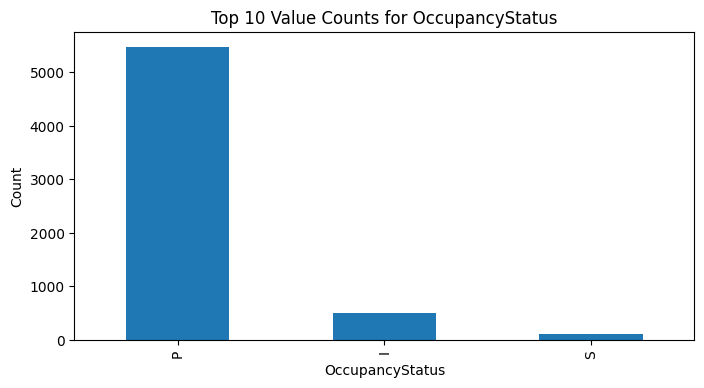

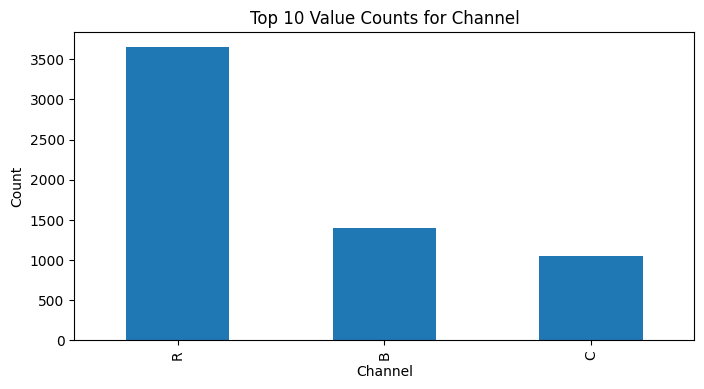

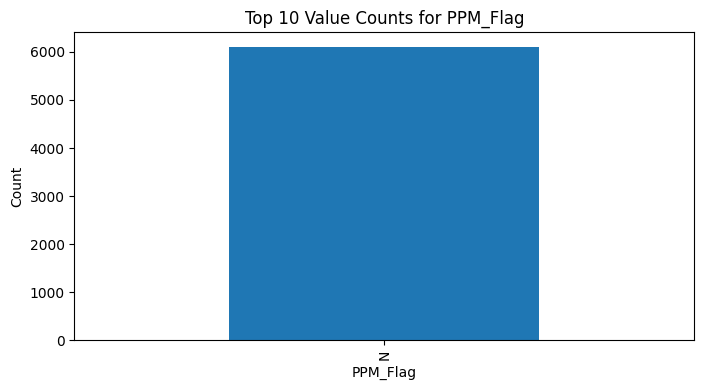

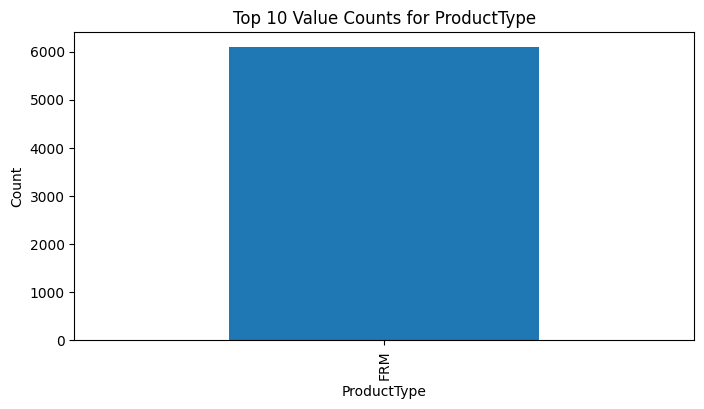

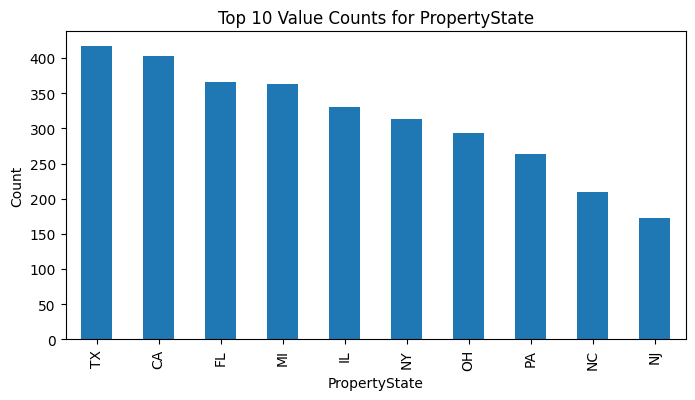

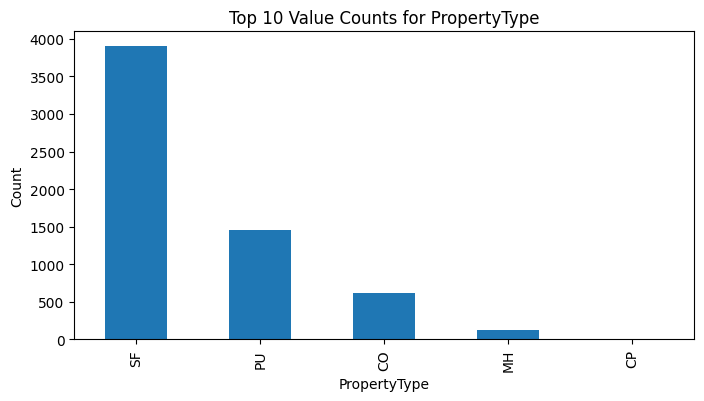

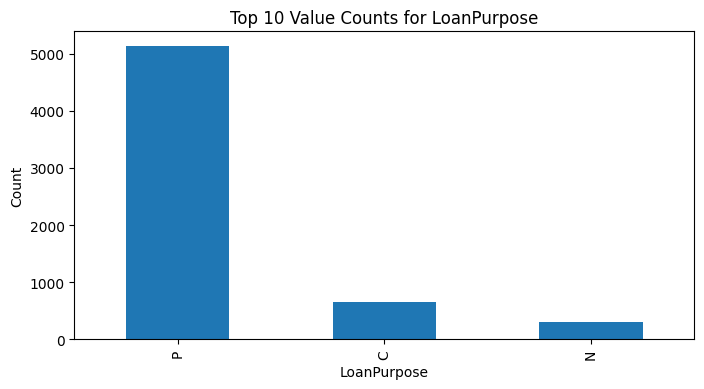

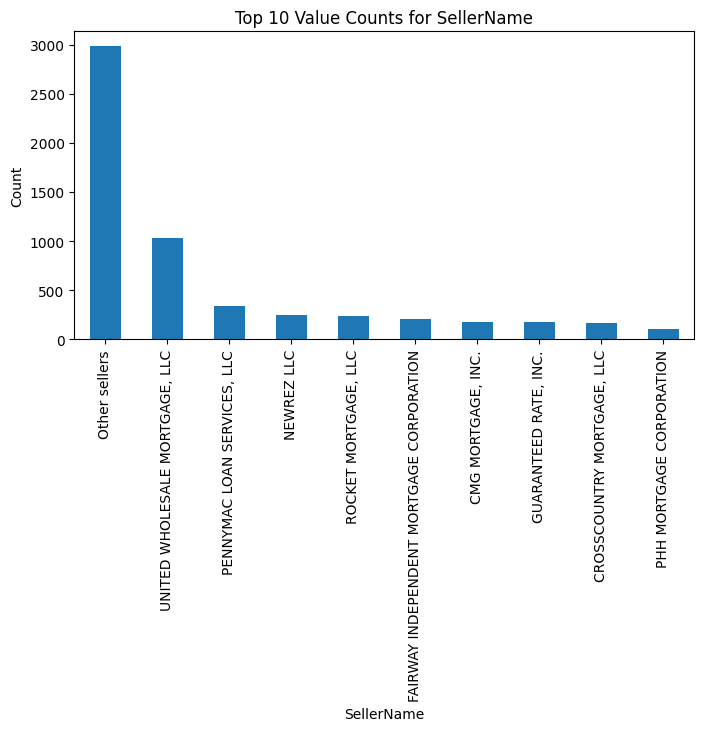

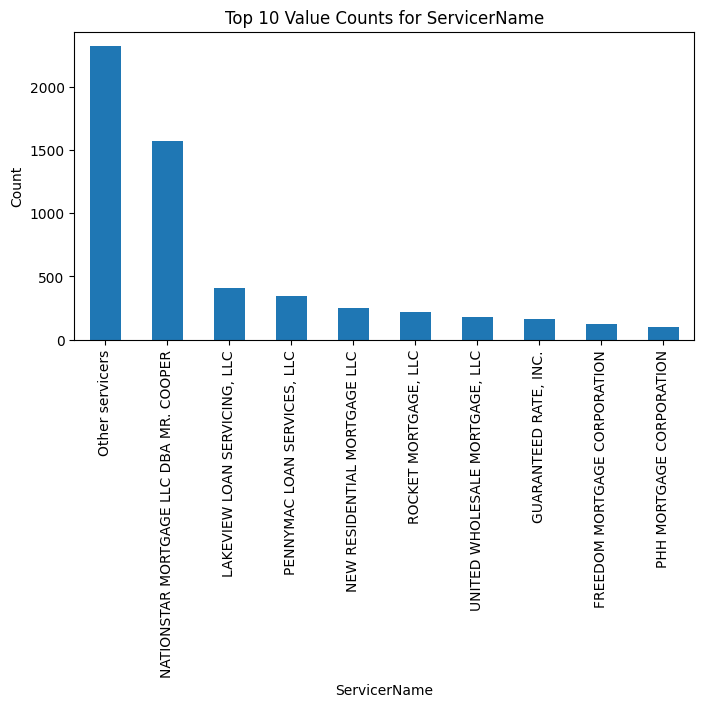

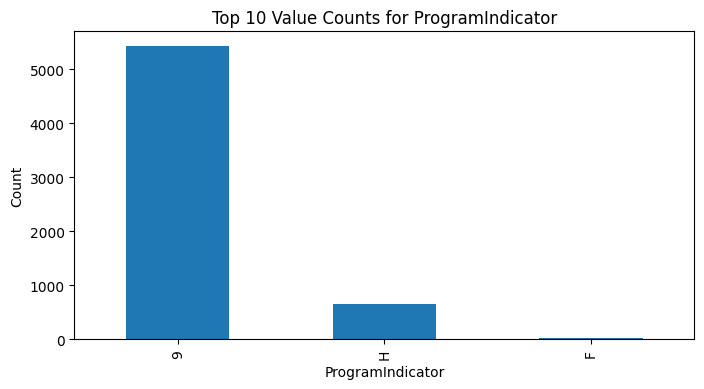

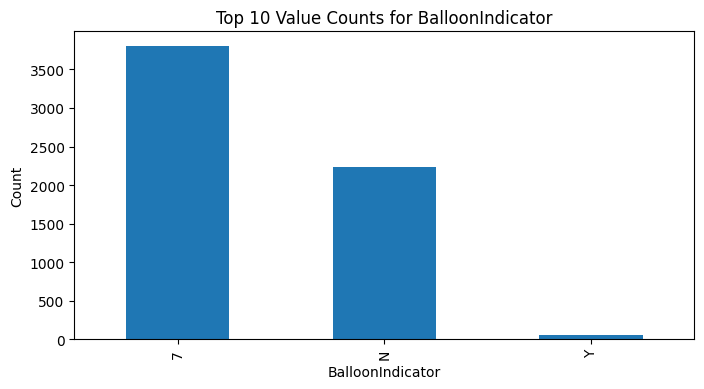

In [231]:
# Bar plots for top categories in each categorical feature
for col in categorical_columns:
    plt.figure(figsize=(8, 4))
    train_df[col].value_counts(dropna=False).head(10).plot(kind='bar')
    plt.title(f'Top 10 Value Counts for {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

In [232]:
# Value counts for categorical features
for col in categorical_columns:
    print(f'\nValue counts for {col}:')
    print(train_df[col].value_counts(dropna=False))


Value counts for OccupancyStatus:
OccupancyStatus
P    5481
I     508
S     112
Name: count, dtype: int64

Value counts for Channel:
Channel
R    3659
B    1397
C    1045
Name: count, dtype: int64

Value counts for PPM_Flag:
PPM_Flag
N    6101
Name: count, dtype: int64

Value counts for ProductType:
ProductType
FRM    6101
Name: count, dtype: int64

Value counts for PropertyState:
PropertyState
TX    417
CA    403
FL    366
MI    363
IL    331
NY    314
OH    294
PA    264
NC    210
NJ    173
IN    171
VA    167
MO    166
GA    166
AZ    151
MN    138
TN    133
MA    123
WA    122
WI    121
CO    113
KY    101
MD    100
SC     94
OR     93
UT     86
KS     81
OK     73
IA     73
AL     71
AR     59
CT     59
NV     56
LA     49
ME     44
NH     41
ID     41
VT     35
NM     34
NE     33
DE     23
WY     20
MT     19
HI     19
ND     17
MS     16
RI     16
SD     12
WV     11
DC      9
AK      5
GU      2
VI      2
PR      1
Name: count, dtype: int64

Value counts for PropertyType:
Pro

In [233]:
train_df.columns.tolist()

['target',
 'CreditScore',
 'FirstPaymentDate',
 'FirstTimeHomebuyerFlag',
 'MaturityDate',
 'MSA',
 'MI_Pct',
 'NumberOfUnits',
 'OccupancyStatus',
 'OriginalCLTV',
 'OriginalDTI',
 'OriginalUPB',
 'OriginalLTV',
 'OriginalInterestRate',
 'Channel',
 'PPM_Flag',
 'ProductType',
 'PropertyState',
 'PropertyType',
 'PostalCode',
 'LoanPurpose',
 'OriginalLoanTerm',
 'NumberOfBorrowers',
 'SellerName',
 'ServicerName',
 'SuperConformingFlag',
 'ProgramIndicator',
 'ReliefRefinanceIndicator',
 'PropertyValMethod',
 'InterestOnlyFlag',
 'BalloonIndicator',
 '0_CurrentActualUPB',
 '0_CurrentInterestRate',
 '0_CurrentNonInterestBearingUPB',
 '0_EstimatedLTV',
 '0_InterestBearingUPB',
 '0_LoanAge',
 '0_MonthlyReportingPeriod',
 '0_RemainingMonthsToLegalMaturity',
 '1_CurrentActualUPB',
 '1_CurrentInterestRate',
 '1_CurrentNonInterestBearingUPB',
 '1_EstimatedLTV',
 '1_InterestBearingUPB',
 '1_LoanAge',
 '1_MonthlyReportingPeriod',
 '1_RemainingMonthsToLegalMaturity',
 '2_CurrentActualUPB',
 '

### Feature Engineering 

In [234]:
train_df_fe = train_df.copy()

Possible Extensions: can create interaction terms (eg. seeing if a first time buyer has low credit score etc.)

In [ ]:
# =============================================================================
# 1. RISK ASSESSMENT FEATURES
# =============================================================================

# Debt Service Ratio - actual monthly debt burden considering interest rates
train_df_fe['DebtServiceRatio'] = train_df_fe['OriginalDTI'] * train_df_fe['OriginalInterestRate'] / 100

# LTV-DTI Interaction - combined leverage and debt risk
train_df_fe['LTV_DTI_Interaction'] = train_df_fe['OriginalLTV'] * train_df_fe['OriginalDTI']

# Credit quality relative to leverage and debt
train_df_fe['CreditScore_LTV_Ratio'] = train_df_fe['CreditScore'] / train_df_fe['OriginalLTV']
train_df_fe['CreditScore_DTI_Ratio'] = train_df_fe['CreditScore'] / (train_df_fe['OriginalDTI'] + 1e-6)

# Risk categories
train_df_fe['HighRiskCredit'] = (train_df_fe['CreditScore'] < 620).astype(int)
train_df_fe['HighLTV'] = (train_df_fe['OriginalLTV'] > 80).astype(int)
train_df_fe['HighDTI'] = (train_df_fe['OriginalDTI'] > 43).astype(int)
train_df_fe['HighInterestRate'] = (train_df_fe['OriginalInterestRate'] > train_df_fe['OriginalInterestRate'].quantile(0.75)).astype(int)

# Combined risk score
train_df_fe['CompositeRiskScore'] = (train_df_fe['HighRiskCredit'] + 
                                    train_df_fe['HighLTV'] + 
                                    train_df_fe['HighDTI'] + 
                                    train_df_fe['HighInterestRate'])


In [ ]:
# =============================================================================
# 2. GEOGRAPHIC FEATURES
# =============================================================================

# State-level risk
state_stats = train_df_fe.groupby('PropertyState').agg({
    'target': 'mean',
    'OriginalUPB': 'median',
    'CreditScore': 'mean'
}).add_suffix('_State')

train_df_fe = train_df_fe.merge(state_stats, left_on='PropertyState', right_index=True, how='left')

# MSA-level risk (if MSA exists)
if 'MSA' in train_df_fe.columns:
    msa_stats = train_df_fe.groupby('MSA').agg({
        'target': 'mean',
        'OriginalUPB': 'median'
    }).add_suffix('_MSA')
    
    train_df_fe = train_df_fe.merge(msa_stats, left_on='MSA', right_index=True, how='left')